In this notebook I am going to try to replicate Figures 11 and 12 from Sadavoy, 2019 (https://ui.adsabs.harvard.edu/abs/2019ApJS..245....2S/abstract)

I am then going to try to adapt it to work for ALMA Band 5 and Band 7

## Load intro things

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

In [3]:
from scipy.interpolate import UnivariateSpline

In [4]:
color = ['red', 'blue', 'green']
ls = ['-', '--', '-.']

## Primary Beam and Centre Point

In [5]:
pb_path = band7_data_folder_path + "IRS63_BAND7_pb.fits"

header, _, pb_map, wcs = read_in_file(pb_path)

ny, nx = pb_map.shape

In [6]:
centre_string = centre_str_band6

centre_ra_deg, centre_dec_deg = find_ra_and_dec(centre_string)

x_cen, y_cen = find_pix(centre_ra_deg, centre_dec_deg, pb_path)

x_cen_int = int(x_cen)        # phase center x pixel
y_cen_int = int(y_cen)        # phase center y pixel

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


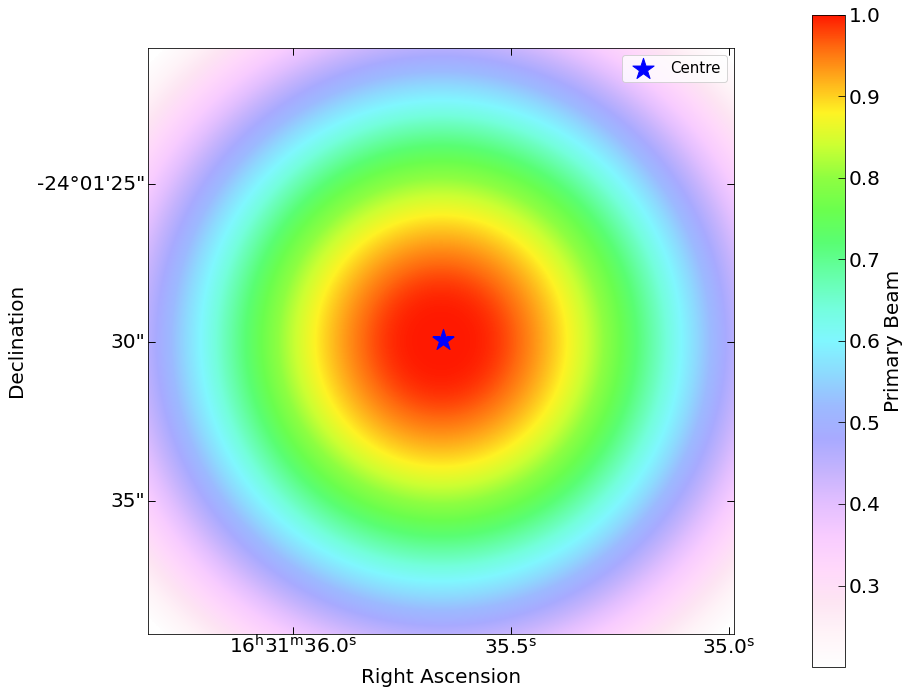

In [7]:
fig, ax = simple_plot(wcs, pb_map, 'Primary Beam', 
                           soft_colormap_v2, 
                           0, nx, 0, ny)


ax.scatter(x_cen, y_cen, marker = '*', s = 500, color = 'blue', label = 'Centre')

ax.legend(fontsize = legend_text_fs)

## Make a radius map

In [8]:
pixel_scale = np.abs(header["CDELT1"]) * 3600  # arcsec/pixel

y_grid, x_grid = np.indices((ny, nx))

radius_map = np.sqrt((x_grid - x_cen)**2 + (y_grid - y_cen)**2) * pixel_scale

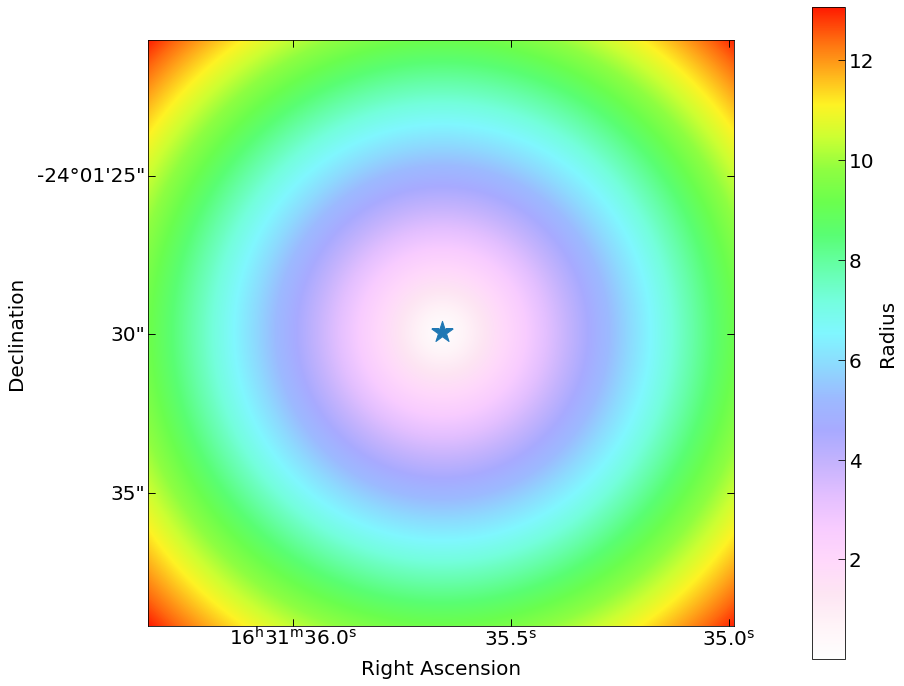

In [9]:
fig, ax = simple_plot(wcs, radius_map, 'Radius', 
                           soft_colormap_v2, 
                           0, nx, 0, ny)


ax.scatter(y_cen, x_cen, marker = '*', s = 500)

## Find slice and make profile

In [10]:
# Only consider the values of pb_map that have a column of x_cent, since our slice is in the centre
column = pb_map[:, x_cen_int]

# Define the y limits of the slice 
y_slice_start = y_cen_int
y_slice_end = ny - 1

# Slice the column from centre to top
pb_slice     = column[y_cen_int : ny]     # step=+1 goes upward
y_slice_arr  = np.arange(y_cen_int, ny)
x_slice_arr  = np.full(len(pb_slice), x_cen_int)

radius_slice = radius_map[y_slice_arr, x_slice_arr]

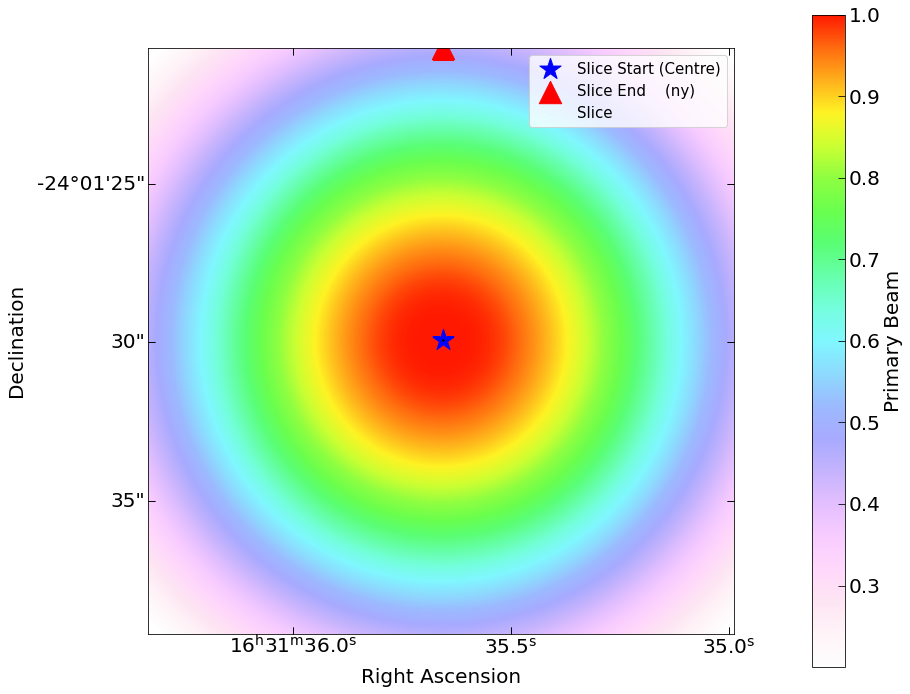

In [11]:
fig, ax = simple_plot(wcs, pb_map, 'Primary Beam', 
                           soft_colormap_v2, 
                           0, nx, 0, ny)


ax.scatter(x_cen, y_slice_start, marker = '*', s = 500, color = 'blue', label = 'Slice Start (Centre)')
ax.scatter(x_cen, y_slice_end,   marker = '^', s = 500, color = 'red', label = 'Slice End    (ny)')

ax.scatter(x_slice_arr, x_slice_arr, marker = '.', s = 0.001, color = 'black', label = 'Slice')

ax.legend(fontsize = legend_text_fs)

## Find $\sigma(r)$ along the slice

In [12]:
sigma_0 = 0.03  # mJy at phase center

sigma_r_raw = sigma_0 / pb_slice

# Make a smooth spline of sigma vs radius
spline = UnivariateSpline(radius_slice[:-1], sigma_r_raw[:-1], s=0.0, k=3)

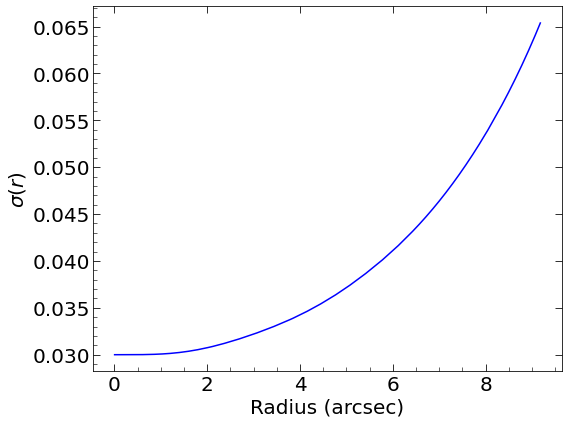

In [13]:
# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(1, 1, figsize=(8,6))

ax.plot(radius_slice, sigma_r_raw, color = 'blue')

ax.set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax.set_ylabel('$\sigma(r)$', fontsize=axis_label_fs)


ax.set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
ax.tick_params(which='minor', length=4, direction="in")


plt.tight_layout()
plt.show()

In [14]:
# r_test = np.linspace(0, 16, len(sigma_r_raw))       # 0–20 arcsec

r_test = np.arange(0, 16.5, 0.3)
sigma_r = spline(r_test)          # interpolated sigma(r)

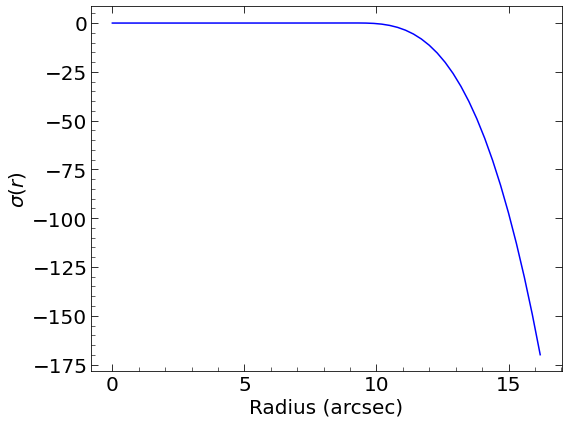

In [15]:
# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(1, 1, figsize=(8,6))

ax.plot(r_test, sigma_r, color = 'blue')

ax.set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax.set_ylabel('$\sigma(r)$', fontsize=axis_label_fs)


ax.set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
ax.tick_params(which='minor', length=4, direction="in")


plt.tight_layout()
plt.show()

## Set up the test radius and use spline to find $\sigma(r)$ at specified radius values

In [16]:
dr_deg = 0.3 / 206265

In [17]:
sn_levels = [5, 10, 20]

prob_band6_norm = []           # normalized differential probabilities per annulus (%)
prob_band6_cumulative = []     # cumulative probabilities per threshold

radius_left = r_test
for sn in sn_levels:
    
    S = sigma_r * sn
    
    
    
    
    
    for rmin, rmax in zip(radius_left[:-1], radius_left[1:]):
        mask = (radius_map >= rmin) & (radius_map < rmax)
        
        dN_dS_annulus = galaxy_probability(S, 'Band 6')
        dN_dS_mean = np.nanmean(dN_dS_annulus)
        
        # Calculate annulus area in deg^2
        area_annulus = np.pi * (rmax**2 - rmin**2)
        area_annulus = 2 * np.pi * ((rmax + rmin)/2) * dr_deg
        
        # Expected number of galaxies in annulus
        N = dN_dS_mean * area_annulus
        
        prob_annuli.append(N)  # append to list here
    
    prob_annuli = np.array(prob_annuli)
    
    # Normalize differential probabilities as percentage of total counts
    prob_annuli_norm = 100 * prob_annuli / np.nansum(prob_annuli)
    prob_band6_norm.append(prob_annuli_norm)
    
    # Compute cumulative probability (%)
    cumulative_prob= np.cumsum(prob_annuli_norm)
    prob_band6_cumulative.append(cumulative_prob)


/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/GalaxyContaminationFunctions.py:49: RuntimeWarning: invalid value encountered in power
  dN_dS = phi * (S/S0)**(alpha) * np.exp(-S/S0)


NameError: name 'prob_annuli' is not defined

## Recreate Figure 11 and 12

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 7))


for i, N in enumerate(sn_levels):
    # Annular detection probability
    ax[0].plot(radius_left[:-1], prob_band6_norm[i], color='black', ls=ls[i], label=f'S/N > {N}')
    
    # Cumulative probability
    ax[1].plot(radius_left[:-1], prob_band6_cumulative[i], color='black', ls=ls[i], label=f'S/N > {N}')
    


ax[0].set_ylabel('Probability of Galaxy in Annulus (%)', fontsize = axis_label_fs)
ax[1].set_ylabel('Cumulative Probability of Galaxy(%)',  fontsize = axis_label_fs)


for i in range(2):
    
    # Add axis labels
    ax[i].set_xlabel(r'Radius (arcsec)', fontsize=axis_label_fs)


    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
    
    ax[i].legend(fontsize = legend_text_fs)


# Mark the peak probability to see if it lines up with the paper
peaks = [9.3, 8.8, 7]

for i in range(3):
    ax[0].axvline(peaks[i], color = color[i], ls = ls[i])
    

plt.tight_layout()
plt.show()